                            SPEAKER RECOGNITION

   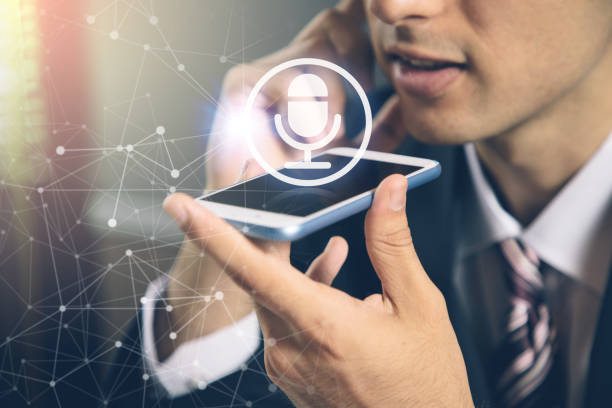


## INTRODUCTION

Speaker recognition and speech recognition are two distinct but related fields within the broader domain of audio signal processing and analysis. Here are the key differences between them:

1. **Objective:**
   - **Speaker Recognition:** The primary goal of speaker recognition is to identify or verify the identity of a speaker based on their unique vocal characteristics, often referred to as speaker "voiceprints" or "biometric signatures." It is a form of biometric authentication.
   - **Speech Recognition:** The main objective of speech recognition is to convert spoken language into text or other forms of commands. Speech recognition systems analyze audio signals to understand and transcribe the spoken words.

2. **Focus:**
   - **Speaker Recognition:** Focuses on the unique characteristics of an individual's voice, such as pitch, tone, accent, and speech patterns, to establish the speaker's identity.
   - **Speech Recognition:** Focuses on understanding and interpreting the linguistic content of spoken words, regardless of the speaker. It involves converting spoken language into a textual representation.

3. **Applications:**
   - **Speaker Recognition:** Commonly used in security systems, access control, and authentication applications where the identity of the speaker needs to be verified.
   - **Speech Recognition:** Applied in various fields, including voice-activated assistants, transcription services, voice commands in smart devices, and interactive voice response (IVR) systems.

4. **Challenges:**
   - **Speaker Recognition:** Faces challenges such as variations in voice due to health, emotional state, or environmental conditions. It also needs to account for potential attempts at voice impersonation.
   - **Speech Recognition:** Challenges include dealing with variations in accents, background noise, and context-dependent language understanding. It requires sophisticated natural language processing (NLP) techniques.

5. **Techniques:**
   - **Speaker Recognition:** Uses techniques such as speaker verification (confirming identity) and speaker identification (naming the speaker) based on feature extraction and pattern matching.
   - **Speech Recognition:** Utilizes techniques such as Hidden Markov Models (HMMs), deep neural networks (DNNs), and recurrent neural networks (RNNs) for acoustic modeling and language modeling.

6. **Output:**
   - **Speaker Recognition:** Outputs the identity or verification result of the speaker.
   - **Speech Recognition:** Outputs the transcribed text or recognized spoken commands.

While speaker and speech recognition have distinct objectives, they can complement each other in applications where both speaker identity and spoken content need to be considered, such as in security systems with voice commands.

Problem Statement: In this project, we have 1500 1 second wav files for each of the 5 speakers. We will try to train a RNN(Recurrent Neural Network) model to predict if our model captures the speaker properly. There are also background noise files on separate folders if we want to use them and generalize our model further. I will implement without using the background noise files. Recurrent Neural Networks (RNNs) are well-suited for certain aspects of speaker recognition due to their ability to model sequential dependencies and capture temporal patterns in data. 

## IMPORTING LIBRARIES

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np

I want to combine the first 2 minutes of the audio files for each speaker and listen to few samples, I am using the kaggle output folder to combine the files.

In [ ]:
# Output directory to clear
output_dir = "/kaggle/working/combined_files"

# Clear the contents of the output directory
shutil.rmtree(output_dir, ignore_errors=True)
os.makedirs(output_dir, exist_ok=True)

print(f"Contents of {output_dir} cleared.")


## Create combined files for each speaker 

Using librosa and soundfile packages to create the combined files.I am only taking the first 120 files from each speaker folder to create 2 min long snippets of each speech.

librosa is a Python package for music and audio analysis. It provides tools to analyze and visualize audio data, including functions for feature extraction, time-series representation, and visualization of audio signals. It is commonly used in the field of music information retrieval and audio signal processing.

soundfile is a Python library for reading and writing sound files. It provides an easy-to-use interface for working with audio files, supporting various formats such as WAV, FLAC, and OGG. soundfile is often used in conjunction with librosa when working with audio data, as it helps to load and save audio files efficiently.

In [ ]:
import librosa
import soundfile as sf

# Path to the dataset
dataset_path = "/kaggle/input/speaker-recognition-dataset/16000_pcm_speeches"

# Output directory to save the combined files
output_dir = "/kaggle/working/combined_files"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# List of speaker folders
speaker_folders = [
    "Benjamin_Netanyau",
    "Jens_Stoltenberg",
    "Julia_Gillard",
    "Magaret_Tarcher",
    "Nelson_Mandela"
]

# Number of files to combine for each speaker
num_files_to_combine = 120

# Iterate over each speaker's folder
for speaker_folder in speaker_folders:
    speaker_folder_path = os.path.join(dataset_path, speaker_folder)

    # List the first num_files_to_combine WAV files in the speaker's folder
    wav_files = [f"{i}.wav" for i in range(num_files_to_combine)]

    # Combine all WAV files into a single long file
    combined_audio = []
    for wav_file in wav_files:
        wav_file_path = os.path.join(speaker_folder_path, wav_file)
        audio, sr = librosa.load(wav_file_path, sr=None)
        combined_audio.extend(audio)

    # Save the combined audio file
    output_file_path = os.path.join(output_dir, f"{speaker_folder}_combined.wav")
    sf.write(output_file_path, combined_audio, sr)

print("Combination complete. Combined files saved in:", output_dir)

IPython is an interactive command-line shell for Python. It provides an enhanced interactive environment for Python programming and is particularly popular among data scientists, researchers, and engineers working in scientific computing, data analysis, and machine learning.

In [ ]:
from IPython.display import display, Audio

# Function to play audio file
def play_audio(audio_path):
    display(Audio(filename=audio_path))

# Play a specific combined audio file
speaker_folder = "Benjamin_Netanyau_combined"
audio_path = os.path.join(output_dir, f"{speaker_folder}.wav")
print(f"Click the play button to listen: {audio_path}")
play_audio(audio_path)


In [ ]:
# Function to play audio file
def play_audio(audio_path):
    display(Audio(filename=audio_path))

# Play a specific combined audio file
speaker_folder = "Nelson_Mandela_combined"
audio_path = os.path.join(output_dir, f"{speaker_folder}.wav")
print(f"Click the play button to listen: {audio_path}")
play_audio(audio_path)

## DATA VISUALIZATIONS

A waveform and spectrogram are two types of visual representations of audio signals:

1. **Waveform:**
   - **Representation:** A waveform is a time-domain representation of an audio signal.
   - **Axis:** The x-axis represents time, and the y-axis represents the amplitude (loudness) of the signal at each point in time.
   - **Features:** It shows how the amplitude of the audio signal changes over time.
   - **Interpretation:** Peaks and valleys in the waveform correspond to changes in air pressure, which are perceived as sound.

2. **Spectrogram:**
   - **Representation:** A spectrogram is a frequency-domain representation of an audio signal.
   - **Axis:** The x-axis represents time, the y-axis represents frequency, and the color/intensity represents the magnitude (energy) of frequencies at different times.
   - **Features:** It provides a 2D representation of how the frequency content of the signal changes over time.
   - **Interpretation:** Dark regions in the spectrogram indicate the presence of certain frequencies at specific times.

The Mel-Frequency Cepstral Coefficients (MFCCs) plot is a representation of the audio signal in the frequency domain. MFCCs are coefficients that collectively represent the short-term power spectrum of a sound signal. The plot visualizes the variations in the spectral content of the audio signal over time.

Here's what the MFCC plot can show:

1. **Time vs. Frequency:** The x-axis represents time, and the y-axis represents different frequency bands. Each column in the plot corresponds to a short segment of time, and the height of the plot at a particular frequency band represents the magnitude or intensity of the signal in that frequency range during that time segment.

2. **Feature Extraction:** MFCCs are used as features for audio processing tasks. Each row in the plot corresponds to one of the MFCC coefficients. These coefficients capture important characteristics of the audio signal, such as the shape of the vocal tract, which is useful for tasks like speech and audio recognition.

3. **Spectral Characteristics:** Peaks and patterns in the plot can indicate specific frequencies or patterns in the audio signal. For example, formants in speech can be identified as concentrations of energy at specific frequencies.

4. **Analysis of Sound Patterns:** By observing how the MFCCs change over time, you can analyze sound patterns, distinguish between different sounds, and extract features for use in machine learning models for tasks like speaker identification, emotion recognition, or speech-to-text.

We will look at some plots for few speakers

In [ ]:
import librosa.display

# Function to plot the waveform, spectrogram, and MFCCs
def plot_audio_features(audio_path):
    # Load audio file
    y, sr = librosa.load(audio_path, sr=None)

    # Extract speaker name from the file path
    speaker_name = os.path.basename(audio_path).split('_')[0]

    # Plot the waveform
    plt.figure(figsize=(15, 10))
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f'Waveform - {speaker_name}')

    # Plot the spectrogram
    plt.subplot(3, 1, 2)
    D = librosa.amplitude_to_db(librosa.stft(y), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram - {speaker_name}')

    # Plot the MFCCs
    plt.subplot(3, 1, 3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, x_axis='time')
    plt.colorbar()
    plt.title(f'MFCCs - {speaker_name}')

    plt.tight_layout()
    plt.show()

# Paths to the combined audio files
audio_paths = [
    '/kaggle/working/combined_files/Benjamin_Netanyau_combined.wav',
    '/kaggle/working/combined_files/Nelson_Mandela_combined.wav'
]

# Plot features for each audio file
for audio_path in audio_paths:
    plot_audio_features(audio_path)


## FEATURE EXTRACTION

Feature extraction is a crucial step in the process of preparing data for machine learning tasks, and its importance lies in several key aspects:

1. **Dimensionality Reduction:** Raw data, especially in audio, image, or text processing, can be high-dimensional. Extracting relevant features helps reduce the dimensionality of the data, making it more manageable and computationally efficient.

2. **Relevant Information Capture:** Feature extraction allows the capture and representation of essential information within the data. Not all raw data is equally informative, and feature extraction helps identify and retain the most relevant aspects for the given task.

3. **Noise Reduction:** By focusing on specific features, the extraction process can help filter out noise or irrelevant details present in the raw data. This can lead to more robust and accurate machine learning models.

4. **Improved Model Performance:** Feature extraction often contributes to improved model performance. Models can better generalize and make predictions when trained on a set of well-defined, informative features.

5. **Facilitation of Learning:** Extracted features can highlight patterns, relationships, or structures in the data that are more conducive to learning. This can lead to faster and more effective training of machine learning models.

6. **Human Interpretability:** In some cases, extracted features are more interpretable and meaningful to humans than the raw data. This interpretability can be crucial for understanding the inner workings of a model and building trust in its predictions.

7. **Domain-Specific Adaptation:** Feature extraction allows the tailoring of data representation to the specific requirements and characteristics of the problem domain. Different tasks may require different sets of features for optimal performance.

8. **Handling of Multimodal Data:** In scenarios where data comes from multiple sources or modalities, feature extraction enables the integration of information from different domains into a common representation, facilitating joint analysis.

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Set the parent directory for speaker folders
parent_dir = "/kaggle/input/speaker-recognition-dataset/16000_pcm_speeches"

# List of speaker folders
speaker_folders = [
    "Benjamin_Netanyau",
    "Jens_Stoltenberg",
    "Julia_Gillard",
    "Magaret_Tarcher",
    "Nelson_Mandela"
]

def extract_features(parent_dir, speaker_folders):
    features = []
    labels = []

    for i, speaker_folder in enumerate(speaker_folders):
        speaker_folder_path = os.path.join(parent_dir, speaker_folder)

        for filename in os.listdir(speaker_folder_path):
            if filename.endswith(".wav"):
                file_path = os.path.join(speaker_folder_path, filename)
                audio, sr = librosa.load(file_path, sr=None, duration=1)
                mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
                
                # Normalize MFCC features
                mfccs = StandardScaler().fit_transform(mfccs)
                
                features.append(mfccs.T)
                labels.append(i)

    return np.array(features), np.array(labels)

# Extract features and labels
X, y = extract_features(parent_dir, speaker_folders)

The numbers in the array represent the extracted MFCC (Mel-frequency cepstral coefficients) features for each frame of audio. Each row in the array corresponds to a frame, and each column corresponds to a specific MFCC feature.

The output will be an array of numbers representing the MFCC coefficients for the first frame of the first audio file.

The interpretation of these numbers can be a bit complex and depends on the specific context of your audio data and the characteristics of the speakers. Generally, MFCCs capture information related to the shape of the vocal tract during the production of speech sounds. Features like the first MFCC may correspond to the overall energy, while higher-order coefficients capture more detailed spectral information.

In a typical set of MFCC coefficients, each coefficient captures different aspects of the audio signal. Here are brief explanations for a few of them:

First Coefficient (MFCC 0): Often referred to as the "constant" term, it represents the overall energy of the signal.

Second Coefficient (MFCC 1): Represents the overall spectral slope and is related to the perceived pitch.

Third Coefficient (MFCC 2): Captures spectral features related to the shape of the vocal tract and is associated with formants in speech.

Fourth Coefficient (MFCC 3): Reflects changes in the spectral envelope and can be related to nasality in speech.

Higher-order Coefficients (MFCC 4 and above): Capture more detailed spectral characteristics, providing information about fine spectral structures in the audio.

It's important to note that the interpretation of these coefficients can vary depending on the specific characteristics of the audio signal and the context of the application. Additionally, the meaning of MFCCs is often more easily understood in the context of speech processing and analysis. If you have access to the documentation or literature associated with your specific dataset or application, that would provide more tailored insights.






In [ ]:
# Print the first few features
for feature in X[:1]:
    print(feature)

In [ ]:
print(tf.config.list_physical_devices('GPU'))

## MODEL SET UP - TRAIN/TEST SPLIT and EVALUATION

Splitting the data into 70% train and the remaining will be split equally into validation and test datasets.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder

# Encode labels with explicit classes
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
label_encoder.classes_ = np.array(speaker_folders)

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shapes of training and validation data
print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)

## TRAINING

When defining the RNN model, relu and softmax are activation functions used in different layers of the neural network model.

ReLU (Rectified Linear Unit):

ReLU is an activation function commonly used in hidden layers of neural networks.
Mathematically, it is defined as (f(x) = \max(0, x)), which means that the output is zero for negative inputs and equal to the input for positive inputs.
ReLU helps introduce non-linearity to the model, allowing it to learn complex patterns.
Softmax:

Softmax is an activation function used in the output layer of a neural network for multi-class classification problems.
It converts the raw output scores (logits) into probability distributions over multiple classes.
The output of the softmax function is a vector where each element represents the probability of the corresponding class.
The class with the highest probability is predicted as the final output.
In the below model architecture, the last layer uses softmax activation to obtain probability distributions over the different classes (speakers) for the final prediction. The preceding layer uses relu activation for introducing non-linearity in the hidden layer. The choice of activation functions depends on the nature of the problem and the desired properties of the network.

During model compilation, the chosen loss function is 'sparse_categorical_crossentropy'. Different types of loss functions serve different purposes, and the choice often depends on the nature of the problem you are trying to solve. Here are some commonly used loss functions:

Mean Squared Error (MSE):

Used for regression problems.
Penalizes the model for large errors.

Binary Crossentropy:

Used for binary classification problems.
Appropriate when the target variable is binary (0 or 1).

Categorical Crossentropy:

Used for multi-class classification problems.
Appropriate when the target variable is categorical and each observation belongs to one and only one class.

Sparse Categorical Crossentropy:

Similar to categorical crossentropy, but more suitable when the target variable is represented as integers (class indices) rather than one-hot encoded vectors.
It avoids the need to explicitly convert the target variable to one-hot encoding.
In the provided code, the problem is a multi-class classification task with a categorical target variable representing different speakers. Therefore, 'sparse_categorical_crossentropy' is a suitable choice for the loss function. It is often used when the target variable is represented as class indices (integers) rather than one-hot encoded vectors. The Adam optimizer is chosen as it is a popular optimization algorithm that adapts the learning rates for each parameter during training.

In the context of setting up neural network layers, the numbers 128 and 64 refer to the number of neurons or units in those particular layers. 

tf.keras.layers.LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])): This is an LSTM (Long Short-Term Memory) layer with 128 units. The LSTM layer is a type of recurrent neural network (RNN) layer that is particularly effective for sequence data.

tf.keras.layers.Dense(64, activation='relu'): This is a dense (fully connected) layer with 64 units and ReLU (Rectified Linear Unit) activation function. Dense layers are used for fully connecting every neuron in one layer to every neuron in the next layer.

tf.keras.layers.Dense(len(speaker_folders), activation='softmax'): This is the output layer with as many units as there are classes (determined by len(speaker_folders)). The softmax activation function is often used in the output layer for multi-class classification problems, as it converts raw scores into probabilities.

These choices (128, 64) are somewhat arbitrary and can be adjusted based on the specific characteristics of your data and the complexity of the problem. The number of units in a layer is a hyperparameter that you can experiment with during model tuning. More complex problems or data may require more units, but this also increases the model's capacity and may lead to overfitting if not balanced.

We are also using early stopping to avoid extra runtime and overfitting on the training dataset. Running for 20 Epochs with adam optimizer for compilation.

In [ ]:
# Define the RNN model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(speaker_folders), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model with EarlyStopping
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32, callbacks=[early_stopping])

# Check if EarlyStopping triggered
if early_stopping.stopped_epoch > 0:
    print("Early stopping triggered at epoch", early_stopping.stopped_epoch + 1)
else:
    print("Training completed without early stopping")

# Plot training vs validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## EVALUATION

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

# Evaluate the model on the test set
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Decode labels back to original format
y_test_decoded = label_encoder.inverse_transform(y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test_decoded, y_pred_decoded, labels=speaker_folders)

# Calculate accuracy
accuracy = accuracy_score(y_test_decoded, y_pred_decoded)
print(f"Test Evaluation Accuracy: {accuracy}")

# Calculate F1 score
f1 = f1_score(y_test_decoded, y_pred_decoded, labels=speaker_folders, average='weighted')
print(f"Weighted F1 Score: {f1}")

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=speaker_folders, yticklabels=speaker_folders)

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha="right")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

We didn't use the background noise here but below you can see some notes on setting up models using background noise for better generalization.

Including background noise in training data can be important for several reasons:

1. **Robustness to Real-world Conditions:** In real-world scenarios, environments are rarely silent. Including background noise in training helps the model become robust to various environmental conditions, ensuring that it can perform well in the presence of noise, just like it would encounter in actual use.

2. **Generalization to Diverse Environments:** Training on data with background noise allows the model to generalize better to different acoustic environments. If the model only learns from clean data, it might struggle to adapt to new environments with varying levels and types of background noise.

3. **Avoiding Overfitting to Clean Data:** Models trained solely on clean data might become too specialized for pristine conditions and may not perform well when exposed to real-world, noisy conditions. Including background noise helps prevent overfitting to idealized scenarios.

4. **Enhancing Privacy and Security:** In some applications, such as voice authentication or speaker recognition, it's crucial for the model to be robust to various conditions, including noisy ones. This ensures that the model is not easily fooled by attempts to mimic a clean voice.

5. **Improving Realism in Synthetic Data Generation:** When creating synthetic datasets for training, incorporating background noise makes the data more realistic. Synthetic data with realistic noise patterns can be valuable for training models, especially when obtaining large amounts of real-world data is challenging.

6. **Meeting Application Requirements:** Depending on the application, the model may need to operate in environments with different noise levels. Training on data with diverse noise conditions ensures that the model meets the specific requirements of the application.

7. **Addressing Variability in User Behavior:** Users may interact with devices or systems in various settings, and their behavior can introduce background noise. Training on diverse data helps the model adapt to the variability in user behavior.

Pleae upvote if you find this notebook helpful